<a href="https://colab.research.google.com/github/crypto-infinity/proai/blob/course5-deep-learning/animali_guida_autonoma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Riconoscimento di animali per auto a guida autonoma

**VisionTech Solutions** vuole sviluppare un sistema di riconoscimento automatico delle immagini per distinguere tra veicoli e animali, con l'obiettivo di ottimizzare le operazioni di monitoraggio della fauna nelle aree urbane, evitando incidenti stradali e proteggendo sia gli animali che i veicoli.

VisionTech Solutions collabora con le amministrazioni comunali per implementare un sistema di monitoraggio in tempo reale nelle città, utilizzando telecamere installate lungo le strade per identificare e classificare veicoli e animali. Questo sistema aiuterà a prevenire incidenti stradali causati dall'attraversamento improvviso di animali, avvisando i guidatori tramite segnali stradali elettronici.

## Benefici:

**Automazione dei Processi:**

* Riduzione del tempo e delle risorse per monitorare manualmente le aree urbane.
* Rilevamento automatico e in tempo reale di animali e veicoli.

**Aumento della Precisione:**

* Utilizzo di una rete neurale convoluzionale (CNN) per garantire alta precisione nella classificazione delle immagini.
* Minimizzazione degli errori umani.

**Efficienza Operativa:**

* Processamento rapido e accurato di grandi volumi di dati, migliorando la risposta agli eventi.
* Maggiore sicurezza per i cittadini e riduzione dei danni ai veicoli.

**Applicazioni Multiple:**

* Sorveglianza e monitoraggio del traffico.
* Analisi del comportamento animale nelle aree urbane.
* Utilizzo dei dati per migliorare le politiche di sicurezza stradale.


## Dettagli del Progetto:

**Dataset:**

* Utilizzo del dataset CIFAR, contenente migliaia di immagini etichettate in varie categorie, inclusi veicoli e animali.

**Algoritmo:**

* Implementazione di una rete neurale convoluzionale (CNN) per l'analisi e la classificazione delle immagini.

**Output:**

* Il sistema classificherà correttamente ogni immagine come veicolo o animale.


## Valutazione del Modello:

**Accuratezza:** Proporzione di immagini classificate correttamente rispetto al totale.

**Precisione:** Qualità delle predizioni positive, indicando la proporzione di immagini correttamente identificate.


## Analisi dei Risultati:

* Identificazione di eventuali pattern di errore.
* Valutazione delle categorie di immagini confuse sistematicamente.
* Esame delle immagini errate e riflessione su possibili migliorie al modello.


## Risultato Finale:

* Presentazione completa della rete neurale convoluzionale e delle sue capacità di discriminazione tra veicoli e animali.
* Discussione dettagliata delle metriche utilizzate e un'analisi critica delle prestazioni e limitazioni del modello.


Questo progetto fornirà a VisionTech Solutions un sistema efficace per migliorare la sicurezza stradale e la gestione della fauna nelle aree urbane, dimostrando le competenze pratiche nell'applicazione del machine learning al riconoscimento delle immagini.

# Implementazione

Il progetto implementa un'analisi per **VisionTech Solutions**, al fine di automatizzare e ottimizzare la classificazione di animali e veicoli per sistemi di telerilevamento, al fine di aumentare la sicurezza per animali e umani.

## Caricamento del Dataset

Il dataset è il CIFAR10 (https://www.cs.toronto.edu/~kriz/cifar.html), che verrà utilizzato come base dati per l'addestramento della nostra rete neurale convoluzionale, come da specifiche di progetto.

Sfrutteremo i metodi di tf.Keras per caricarlo, dopodichè ne mostreremo un estratto: https://www.tensorflow.org/apidocs/python/tf/keras/datasets/cifar10/loaddata

In [ ]:
# Dependencies imports

#Generics
import tensorflow as tf
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

#Resampler
from imblearn.over_sampling import ADASYN

#Base Deep Learning layers
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, AveragePooling2D, GlobalAveragePooling2D, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping

#Data Augmentation layers
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast, RandomBrightness

#Classification metrics
from sklearn.metrics import confusion_matrix, classification_report

# ResNet50
from tensorflow.keras.applications import ResNet50, resnet50

In [ ]:
# Loading the CIFAR10 dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Il dataset si compone di due split, Train e Test, suddiviso in features and target. Le nostre features sono un array numpy rappresentante un insieme di immagini 32x32 in formato RGB (3 canali). Verifichiamo la dimensione dei tensori:

In [ ]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

E mostriamo un esempio di immagine e di relativa label:

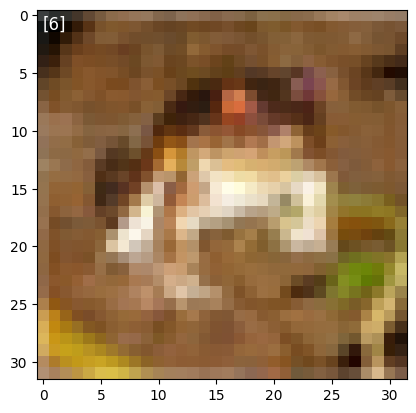

In [ ]:
# Plotting the first image

plt.imshow(X_train[0]);
plt.text(0, 0, y_train[0], color='white', fontsize=12, verticalalignment='top', horizontalalignment='left')
plt.show()

## Tipologia e distribuzione delle labels nel dataset

Prima di cominciare con il preprocessing, verifichiamo quali sono le classi target e la relativa distribuzione:

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

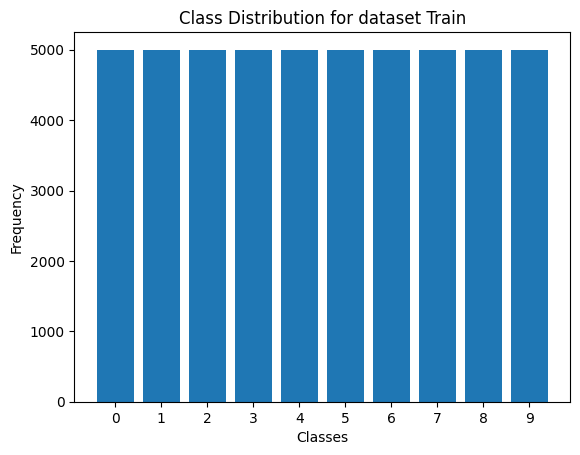

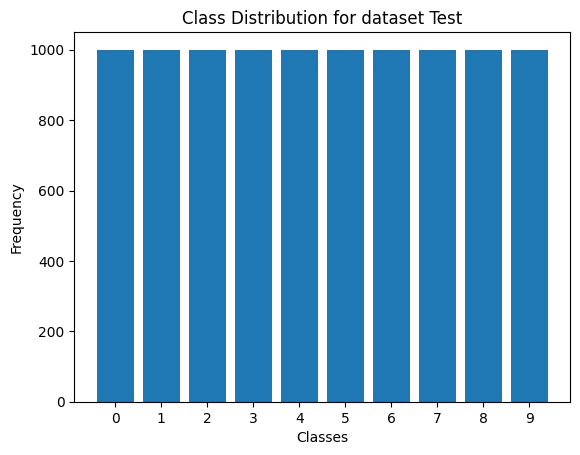

In [ ]:
# Classes distributions

def print_target_distribution(dataset, dataset_name=""):
    """
    Plot distribution of classes in given dataset.

    dataset: the dataset to plot.
    dataset_name: the name of the dataset.
    """

    unique, counts = np.unique(dataset, return_counts=True)

    plt.bar(unique, counts)
    plt.xticks(unique)
    plt.xlabel("Classes")
    plt.ylabel("Frequency")
    plt.title(f"Class Distribution for dataset {dataset_name}")
    plt.show()

print_target_distribution(y_train, "Train")
print_target_distribution(y_test, "Test")

Evinciamo che la distribuzione del target è perfettamente regolare, con lo stesso numero di osservazioni per ciascuna classe.

Come mostrato nell'articolo dell'università di Toronto, e come si evince dall'istogramma sopra, il dataset possiede 10 classi, divise tra vari **veicoli** e **animali**. La richiesta del progetto è la classificazione di queste due macrocategorie, perciò ridefiniremo il problema in una **classificazione binaria**.

## Preprocessing del dataset

Effettuiamo quindi la conversione delle classi presenti in *y_train* e *y_test* e la normalizzazione dell'array delle immagini presenti in *X_train* e *X_test*.

### Conversione delle classi

Cominciamo dal primo task, sostituendo le classi rispettivamente in **0** e **1**, dove 0 rappresenta un veicolo e 1 rappresenta un animale.

In [ ]:
# Classes conversion in 0=Veichle and 1=Animal

veichle_class_map = [0,1,8,9]
animal_class_map = [2,3,4,5,6,7]

y_train = np.vectorize(lambda x: 0 if x in veichle_class_map else 1)(y_train)
y_test = np.vectorize(lambda x: 0 if x in veichle_class_map else 1)(y_test)

In [ ]:
classes_map = { "0": "Veicolo", "1": "Animale" }

In [ ]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1]), array([20000, 30000])), (array([0, 1]), array([4000, 6000])))

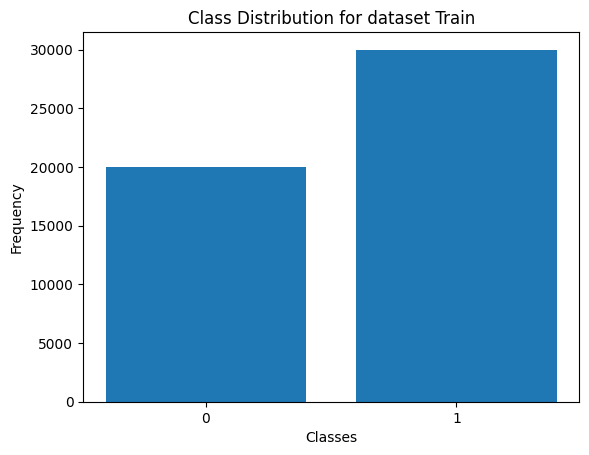

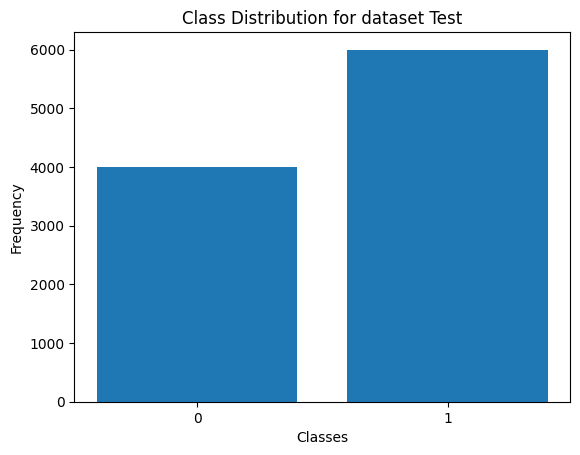

In [ ]:
print_target_distribution(y_train, "Train")
print_target_distribution(y_test, "Test")

## Resampling delle classi

Notiamo subito che la conversione ha introdotto sbilanciamento tra le classi. Effettuiamo quindi un passaggio di un resampler per correggere l'anomalia e ribilanciare il tutto. In questo notebook, utilizzeremo la tecnica **ADASYN** (https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html) per generare nuovi sample sintetici per la classe di minoranza **0**:

In [ ]:
# Oversampling with ADASYN

def resample_dataset(resampler, X, y):
    """
    Resample dataset with resampler. Reshape features to 2D array, fit resampler, invert reshape and return new features.

    Args:
        resampler (ADASYN): the resampler instance to use
        X (np.array): Features
        y (np.array): Target
        is_train (bool, optional): If True, fit resampler. Defaults to False.

    Returns:
        np.array: Resampled features
    """

    #Reshaping features
    X_reshaped = X.reshape(X.shape[0], -1)

    #ADASYN Fit
    X_resampled, y_resampled = resampler.fit_resample(X_reshaped, y)

    #Inverting reshape
    X_resampled = X_resampled.reshape(X_resampled.shape[0], 32, 32, 3)

    #Returning new features
    return X_resampled, y_resampled

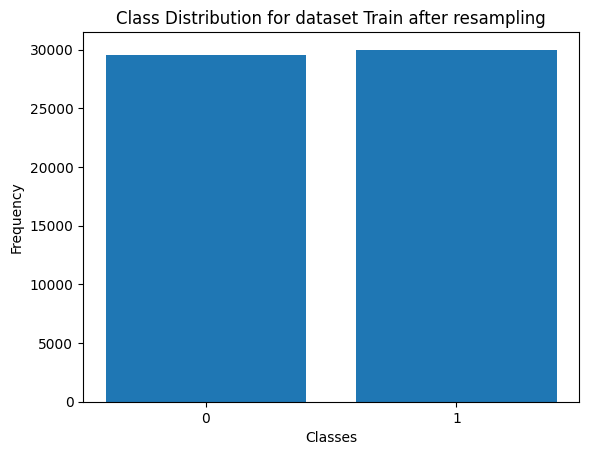

In [ ]:
adasyn_train = ADASYN()

X_train, y_train = resample_dataset(adasyn_train, X_train, y_train)

print_target_distribution(y_train, "Train after resampling")

In [ ]:
print(f"New observations added on train ds: {X_train.shape[0] - 50000}") #number of original observations

New observations added on train ds: 9548


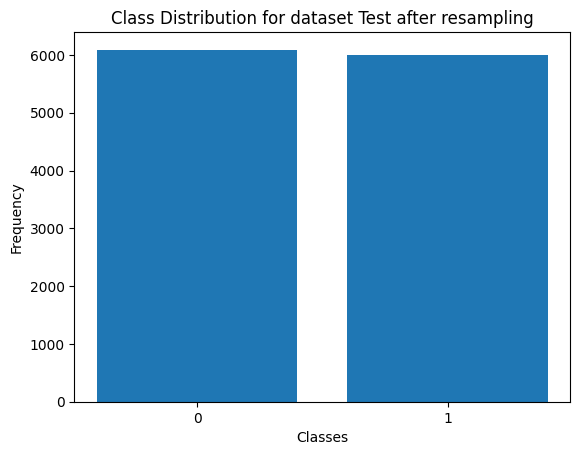

(12090, 32, 32, 3)

In [ ]:
adasyn_test = ADASYN()

X_test, y_test = resample_dataset(adasyn_test, X_test, y_test)

print_target_distribution(y_test, "Test after resampling")

X_test.shape

In [ ]:
print(f"New observations added on train ds: {X_test.shape[0] - 10000}") #number of original observations

New observations added on train ds: 2090


## Preprocessing delle immagini

Ora che le classi target sono state bilanciate, applichiamo all'intero dataset la **normalizzazione** sui tre canali RGB dei dataset delle features (le nostre immagini). Ne creiamo una copia aggiuntiva poichè utilizzeremo anche la funzione preprocess_input() di un modello pretrained (ResNet50) per il secondo esperimento, partendo dal dataset resampled.

In [ ]:
# Images normalization

X_train_normalized = np.float32(X_train) / 255.0
X_test_normalized = np.float32(X_test) / 255.0

E verifichiamone la corretta applicazione:

In [ ]:
np.max(X_train_normalized), np.min(X_train_normalized)

(np.float32(1.0), np.float32(0.0))

In [ ]:
X_train_normalized.shape, X_test_normalized.shape

((59548, 32, 32, 3), (12090, 32, 32, 3))

Effettueremo, successivamente, tentativi di applicazione di layers di data augmentation. Al momento, comunque, le nostre features sono pronte per essere date in pasto alle reti neurali.

## Definizione dell'architettura della Convolutional Neural Network

Per l'analisi di feature spaziali nelle immagini, le reti convoluzionali risultano particolarmente adatte. Come da requisiti di progetto, monteremo quindi una **CNN** effettuando differenti test su molteplici iperparametri e molteplici configurazioni di layers.

Effettueremo due esperimenti separati, e al termine ne confronteremo i risultati:

* Effettueremo il training di alcune configurazioni di CNN from-scratch, implementando manualmente i layer convoluzionali 2D, i GlobalAveragePooling, i Dense layer e i Dropout. In una specifica configurazione, testeremo anche l'applicazione di alcuni layer di Data Augmentation.
* Effettueremo Transfer Learning dall'architettura ResNet50 (https://arxiv.org/abs/1512.03385) sui pesi del dataset ImageNet (https://ieeexplore.ieee.org/document/5206848).

### CNN from-scratch

Iniziamo con la definizione di alcune configurazioni di una rete neurale convoluzionale:

In [ ]:
# Defining CNN configs

tf.keras.backend.clear_session()

CNN_configs = {
    "CNN_AdamStd" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(32, (3, 3), activation='relu', name="FirstConvLayer"),
        AveragePooling2D(pool_size=(2, 2), name="FirstPoolLayer"),
        Dropout(0.01, name="SecondDropoutLayer"),

        #SecondConvBlock
        Conv2D(64, (2, 2), activation='relu', name="SecondConvLayer"),
        GlobalAveragePooling2D("channels_last",name="SecondPoolLayer"), #Replaces Flatten() in modern CNNs

        #DenseBlock
        Dense(128, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="CNN_AdamStd"),

        "optimizer" : "adam",
        "epochs" : 30,
        "history" : None
    },
    "CNN_AdamLarge" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(64, (3, 3), activation='relu', name="FirstConvLayer"),
        MaxPooling2D(pool_size=(2, 2), name="FirstMaxPoolLayer"),

        #SecondConvBlock
        Conv2D(128, (2, 2), activation='relu', name="SecondConvLayer"),
        MaxPooling2D(name="SecondMaxPoolLayer"),

        #Regolarization Block
        Dropout(0.2, name="SecondDropoutLayer"),
        GlobalAveragePooling2D("channels_last",name="GlobalAveragePoolLayer"),

        #DenseBlock
        Dense(256, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="CNN_AdamLarge"),

        "optimizer" : "adam",
        "epochs" : 30,
        "history" : None
    },
    "CNN_AdamLargeWithAugmentation" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #Augmentation Block
        RandomFlip(mode="horizontal_and_vertical", name="AugLayer1"),
        RandomRotation(factor=0.1, name="AugLayer2"),
        RandomZoom(height_factor=0.1, width_factor=0.1, name="AugLayer3"),
        RandomContrast(factor=0.1, name="AugLayer4"),

        #FirstConvBlock
        Conv2D(64, (3, 3), activation='relu', name="FirstConvLayer"),
        MaxPooling2D(pool_size=(2, 2), name="FirstMaxPoolLayer"),

        #SecondConvBlock
        Conv2D(128, (2, 2), activation='relu', name="SecondConvLayer"),
        MaxPooling2D(name="SecondMaxPoolLayer"),

        #Regolarization Block
        Dropout(0.2, name="SecondDropoutLayer"),
        GlobalAveragePooling2D("channels_last",name="GlobalAveragePoolLayer"),

        #DenseBlock
        Dense(256, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="CNN_AdamLargeWithAugmentation"),

        "optimizer" : "adam",
        "epochs" : 50,
        "history" : None
    },
    "CNN_RMSProp_1layer" : {
        "network" : Sequential([

        #InputLayer
        Input(shape=(32, 32, 3), name="InputLayer"),

        #FirstConvBlock
        Conv2D(32, (3, 3), activation='relu', name="FirstConvLayer"),
        MaxPooling2D(pool_size=(2, 2), name="FirstPoolLayer"),
        GlobalAveragePooling2D("channels_last",name="GlobalAveragePoolLayer"),

        #DenseBlock
        Dense(64, activation='relu', name="FirstDenseLayer"),
        Dense(1, activation='sigmoid', name="OutputLayer")

        ],
        name="vanillaCNN_RMS_1Conv"),

        "optimizer" : "adam",
        "epochs" : 20,
        "history" : None
    },
}


E verifichiamone pesi/gradienti da calcolare e shapes per ogni layer, al fine di assicurarci che sia stata montata correttamente. Utilizzeremo anche la funzione di early stopping di Keras, per risparmiare tempo computazionale in caso la validation loss non diminuisca per più di 5 epoche di training.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
for index, nn in enumerate(CNN_configs):

    CNN_configs[nn]["network"].summary()

    CNN_configs[nn]["network"].compile(
        optimizer=CNN_configs[nn]["optimizer"],
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    print("\n")

Model: "CNN_AdamStd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstConvLayer (Conv2D)         │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstPoolLayer                  │ (None, 15, 15, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondDropoutLayer (Dropout)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondConvLayer (Conv2D)        │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ SecondPoolLayer                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstDenseLayer (Dense)         │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,601 (68.75 KB)

 Trainable params: 17,601 (68.75 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "vanillaCNN_RMS_1Conv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ FirstConvLayer (Conv2D)         │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstPoolLayer (MaxPooling2D)   │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePoolLayer          │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FirstDenseLayer (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutputLayer (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%%time

for index, nn in enumerate(CNN_configs):
    print("\nBeginning training of network: " + CNN_configs[nn]["network"].name)

    CNN_configs[nn]["history"] = CNN_configs[nn]["network"].fit(
        X_train_normalized,
        y_train,
        epochs=CNN_configs[nn]["epochs"],
        batch_size=32,
        validation_data=(X_test_normalized, y_test),
        callbacks=[early_stopping]
    )


Beginning training of network: CNN_AdamStd
Epoch 1/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.7966 - loss: 0.4433 - val_accuracy: 0.8938 - val_loss: 0.2685
Epoch 2/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8799 - loss: 0.2878 - val_accuracy: 0.8933 - val_loss: 0.2517
Epoch 3/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8927 - loss: 0.2595 - val_accuracy: 0.9031 - val_loss: 0.2350
Epoch 4/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8951 - loss: 0.2514 - val_accuracy: 0.9007 - val_loss: 0.2350
Epoch 5/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8979 - loss: 0.2470 - val_accuracy: 0.9048 - val_loss: 0.2336
Epoch 6/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9065 - loss: 0.2321 - val_accuracy: 0.9127 - val_loss: 0.2130
Epoch 7/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9081 - loss: 0.2290 - val_accuracy: 0.9118 - val_loss: 0.2112
Epoch 8/30
1861/1861 ━━━━━━━━━━━━━━━━━━

Il maggior numero di filtri e layers della rete **CNN_AdamLarge** sembra catturare meglio le feature spaziali, restituendo un'accuracy di alcuni punti percentuale in più rispetto alle colleghe.

Dimostriamo questo punto mostrando i grafici dell'accuracy sul validation set (che nel nostro caso equivale al test_set):

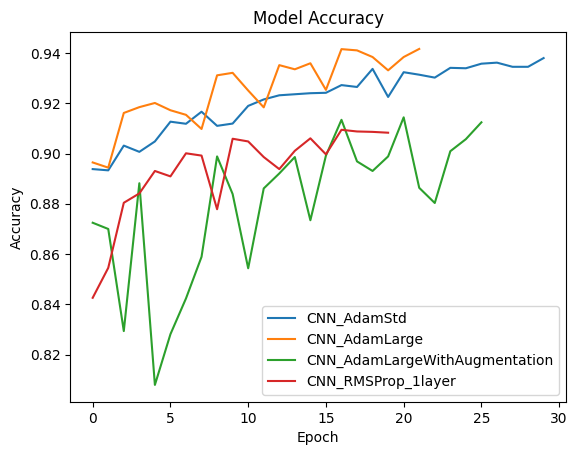

In [ ]:
for hist in CNN_configs:
    plt.plot(CNN_configs[hist]["history"].history['val_accuracy'], label=hist)

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

E analizziamo il report di classificazione, per verificare le metriche in formato numerico (*Accuracy* e *Precision*), come richiesto dalle specifiche di progetto.

In [ ]:
y_pred = CNN_configs["CNN_AdamLarge"]["network"].predict(X_test_normalized)
y_pred = (y_pred > 0.5).astype(int)

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Plot Confusion Matrix

def plot_cm(y, y_pred):
    """
    Plots the confusion matrix for the model predictions.

    y: the true labels.
    y_pred: the predicted labels.
    """

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix")
    plt.xlabel("Valori predetti")
    plt.ylabel("Valori reali")
    plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      6090
           1       0.93      0.95      0.94      6000

    accuracy                           0.94     12090
   macro avg       0.94      0.94      0.94     12090
weighted avg       0.94      0.94      0.94     12090



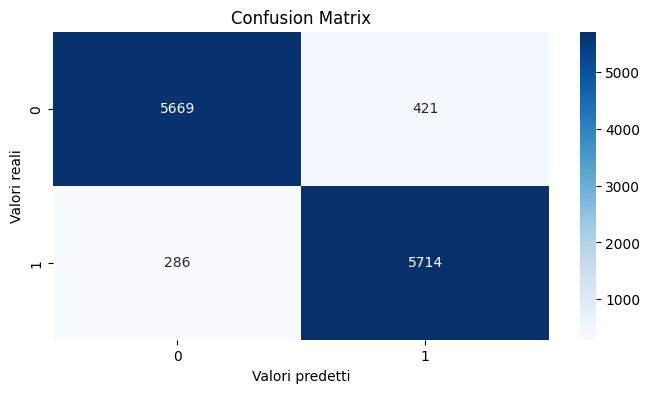

In [ ]:
plot_cm(y_test, y_pred)

### Transfer Learning con ResNet50

Proviamo ora, invece, ad usare i layer convoluzionali dell'architettura **ResNet50**, cambiando solamente i layer densi per convertire la predizione in un task di classificazione binario.

ResNet50 si trova nei primi 50 modelli per la classificazione sul dataset CIFAR10 secondo https://paperswithcode.com/sota/image-classification-on-cifar-10, posizione 47 ad oggi, ed è integrata in Keras. Perciò la utilizzeremo come modello convoluzionale base per il nostro transfer learning.

Cominciamo con l'instanziare l'oggetto, importando solo i layer convoluzionali:

In [ ]:
# ResNet50 base setup

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


E risparmiamo tempo computazionale impostando tutti questi layers come non-trainabili:

In [ ]:
for layers in base_model.layers:
    layers.trainable = False

Costruiamoci sopra il layer denso + l'output layer comune anche alle altre reti precedentemente definite con le API funzionali di tf.Keras:

In [ ]:
# Transfer Learning and fine tuning with ResNet50 (base_model)

tf.keras.backend.clear_session()

base_model_output = base_model.output
pooling = GlobalAveragePooling2D()(base_model_output)
dense = Dense(128, activation='relu')(pooling)
output = Dense(1, activation='sigmoid')(dense)
new_model = Model(inputs=base_model.input, outputs=output)

In [ ]:
new_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Ed effettuiamone il train su un dataset opportunamente processato, come citato precedentemente:

In [ ]:
new_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

X_train_resnet = preprocess_input(X_train)
X_test_resnet = preprocess_input(X_test)

In [ ]:
# Training for ResNet50 base model

new_model.fit(
    X_train_resnet,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_resnet, y_test),
    callbacks=[early_stopping]
)

%time

Epoch 1/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 140s 75ms/step - accuracy: 0.9235 - loss: 0.1981 - val_accuracy: 0.9315 - val_loss: 0.1744
Epoch 2/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 111s 59ms/step - accuracy: 0.9441 - loss: 0.1428 - val_accuracy: 0.9356 - val_loss: 0.1732
Epoch 3/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 112s 60ms/step - accuracy: 0.9544 - loss: 0.1182 - val_accuracy: 0.9335 - val_loss: 0.1688
Epoch 4/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 113s 61ms/step - accuracy: 0.9665 - loss: 0.0905 - val_accuracy: 0.9337 - val_loss: 0.1832
Epoch 5/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 109s 58ms/step - accuracy: 0.9733 - loss: 0.0706 - val_accuracy: 0.9325 - val_loss: 0.2124
Epoch 6/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 111s 60ms/step - accuracy: 0.9801 - loss: 0.0537 - val_accuracy: 0.9341 - val_loss: 0.2303
Epoch 7/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 112s 60ms/step - accuracy: 0.9843 - loss: 0.0417 - val_accuracy: 0.9352 - val_loss: 0.2594
Epoch 8/30
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 112s 60ms/step - accuracy: 

E calcoliamo ora il valore delle predizioni corrette come fatto in precedenza:

In [ ]:
y_pred_resnet = new_model.predict(X_test_resnet)
y_pred_resnet = (y_pred_resnet > 0.5).astype(int)

378/378 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step


In [ ]:
print(classification_report(y_test, y_pred_resnet))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6090
           1       0.92      0.94      0.93      6000

    accuracy                           0.93     12090
   macro avg       0.93      0.93      0.93     12090
weighted avg       0.93      0.93      0.93     12090



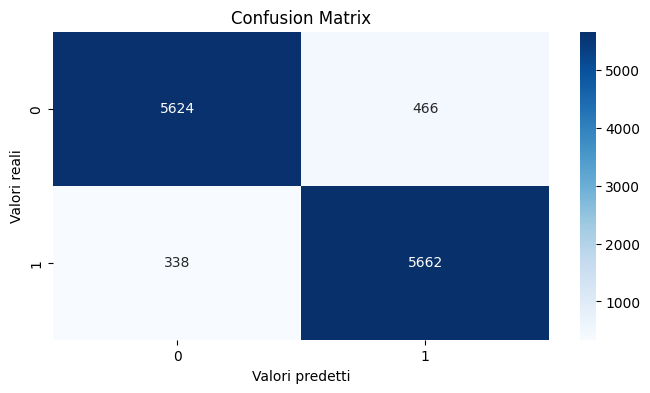

In [ ]:
plot_cm(y_test, y_pred_resnet)

Gli esperimenti mostrano che entrambe le reti producono risultati soddisfacenti (con circa il 94% di accuracy e valori simili di F1 per le due classi).



## Analisi dei risultati ottenuti

Per meglio comprendere la capacità del modello di classificare correttamente se l'immagine si tratta di un veicolo o di un animale, mostriamo graficamente le metriche anticipate sopra e le commentiamo, sfruttando come riferimento la rete da noi allenata **CNN_AdamLarge**:

In [ ]:
# Plot metrics (accuracy, precision and recall) for a given model

def plot_metrics(model, dataset):
    """
    Plots the metrics (accuracy, precision and recall) of the model on the given dataset.

    model: the model to evaluate.
    dataset: the dataset to evaluate the model on.
    """

    X, y = dataset
    y_predictions = model.predict(X)
    y_predictions = (y_predictions > 0.5).astype(int)

    report = classification_report(y, y_predictions, output_dict=True)

    metrics = ['precision', 'recall', 'f1-score']
    classes = ['0', '1']
    classes_labels = [classes_map[cls] for cls in classes]

    fig, axs = plt.subplots(1, 3, figsize=(9, 6))

    for i, metric in enumerate(metrics):
        values = [report[str(cls)][metric] for cls in classes]
        axs[i].bar(classes_labels, values)
        axs[i].set_yticks(np.arange(0, 1.0, 0.05))
        axs[i].set_title(metric.capitalize())

    plt.tight_layout()
    plt.show()

378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


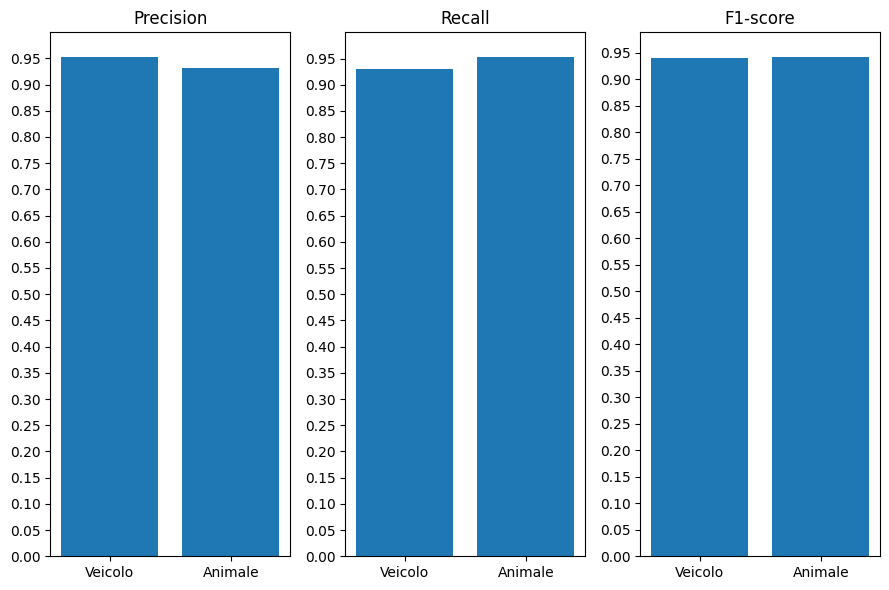

In [ ]:
plot_metrics(CNN_configs["CNN_AdamLarge"]["network"], (X_test_normalized, y_test))

Dai dati mostrati sopra, il 92% delle predizioni classificate come positive sono corrette per la classe Veicolo e il 96% per la classe animale (precision).

Mostriamo, infine, 20 immagini tra quelle classificate erroneamente, verificandole su entrambe le reti, per comprendere se c'è sistematicità nel processo:

In [ ]:
# Plotting first 20 wrongly-classified images

def show_misclassified_images(y, y_pred, images_to_plot=20):
    """
    Plots wrongly classified images along with their true and predicted labels.

    y: the true labels.
    y_pred: the predicted labels.
    images_to_plot: the number of images to plot.
    """

    # Ravel y and y_pred to 1D array
    y = y.ravel()
    y_prediction = y_pred.ravel()

    # Get indices of wrongly classified images
    wrongly_classified_indices = np.where(y != y_prediction)[0]

    # Defining the subplot grid
    fig, axs = plt.subplots(4, 5, figsize=(10, 10))
    axs = axs.flatten()

    # Enumerates over the wrongly classified images
    for i, idx in enumerate(wrongly_classified_indices[:images_to_plot]):
        # Plot the image
        axs[i].imshow(X_test[idx])
        axs[i].axis('off')

        # Mapping labels
        true_label = classes_map[str(y[idx])]
        predicted_label = classes_map[str(y_prediction[idx])]

        # Setting plot title
        axs[i].set_title(f"True: {true_label}\nPred: {predicted_label}")

    # Hiding overflow axes
    for j in range(len(wrongly_classified_indices[:images_to_plot]), len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

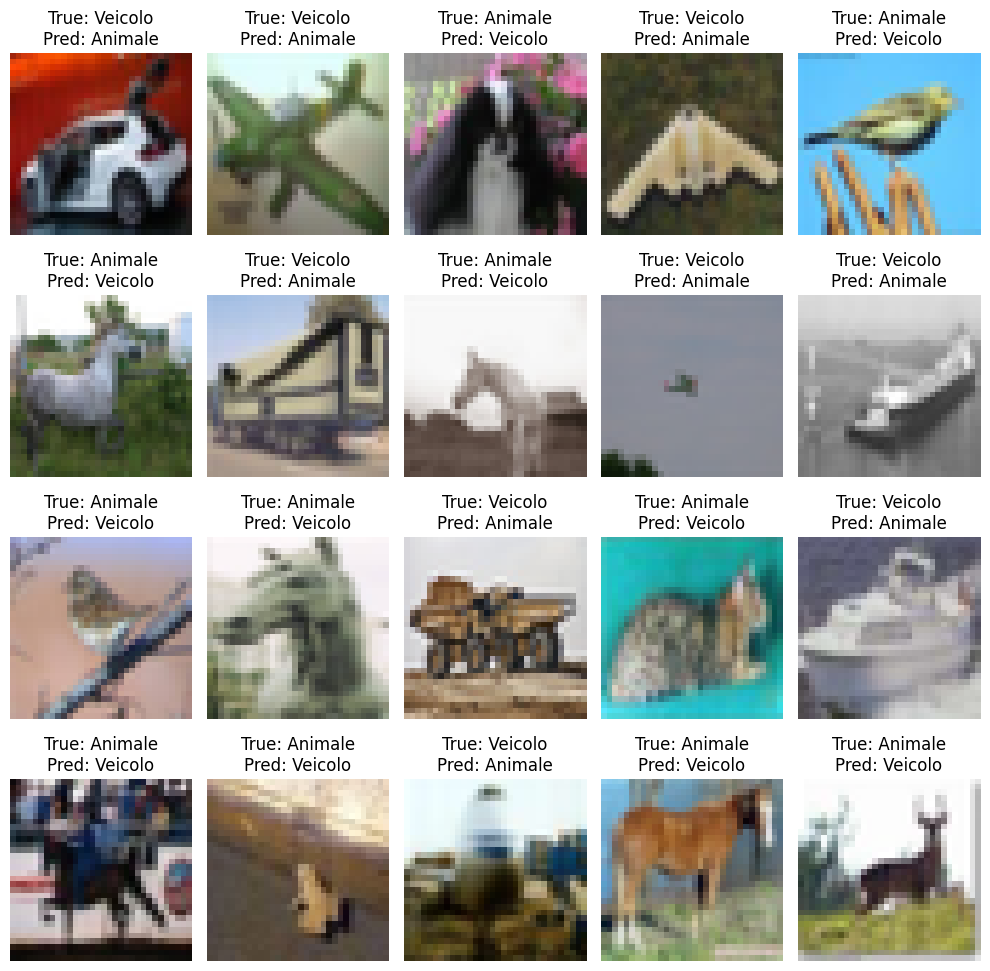

In [ ]:
show_misclassified_images(y_test, y_pred_resnet)

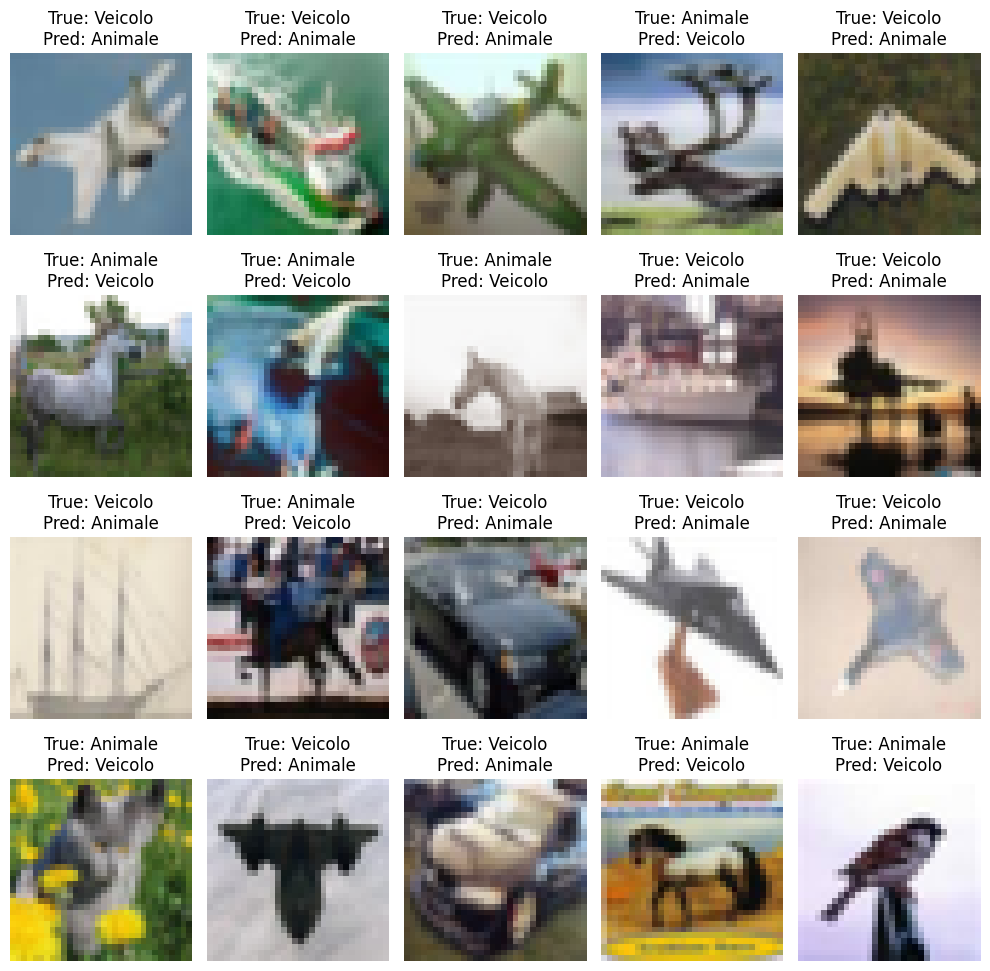

In [ ]:
show_misclassified_images(y_test, y_pred)

Fatto interessante: notiamo che alcuni tipi di veicoli e di animali sembrano essere più soggetti a classificazioni non corrette da entrambe le reti (nello specifico, le classi originali del dataset **"airplane"** e **"horse"**, sia con l'approccio del transfer learning che dalla rete creata from-scratch). Sotto traiamo alcune conclusioni e tenteremo di dare un'interpretazione di come è possibile migliorare ulteriormente questa analisi.

## Prossimi sviluppi e miglioramenti

La rete neurale, nelle diverse configurazioni sperimentate, possiede in generale buona capacità predittiva, con un'accuracy che raggiunge e supera il **94%**.

Dati alcuni risultati evidenziati dalle metriche e dalle analisi qualitative effettuate, suggeriamo comunque alcune aree di miglioramento che è possibile valutare:

* Uso di tecniche più avanzate di **Data Augmentation**: le immagini del dataset CIFAR10 sono già in numero importante, ma passare attraverso dei layer di augmentation delle immagini in input alla rete neurale (esperimento effettuato in forma lieve con la rete CNN_AdamLargeWithAugmentation, con semplici trasformazioni, nonostante una peggiore performance rispetto alle colleghe) potrebbe aumentare le performance del modello.

* **Aumento del numero** delle immagini nel dataset per le classi classificate non correttamente: nel nostro notebook, abbiamo usato ADASYN per compensare lo sbilanciamento di immagini della classe **veicolo** contro la classe **animale**. La presenza di reali samples in maggior numero, che non richiedano la generazione di elementi sintetici, è sicuramente da preferire ove possibile, e potrebbe fornire classificazioni più accurate, in particolare per le immagini di tipo **airplane** e **horse**.

* Uso di **modelli più semplici** per la classificazione, sfruttando ResNet50 per la parte convoluzionale. Questo permette di far fare il lavoro complesso alla rete, consentendo di sfruttare il training già effettuato, semplificando notevolmente l'effettiva parte di classificazione mantenendo comunque un buon compromesso per le performances.

* Training delle reti per un **maggiore numero di epoche**: le attuali reti sono state allenate per un massimo di 30 epoche per questioni di capacità computazionale. E' possibile testare come queste si comportano con 50 o 100 epoche (i grafici delle accuracy suggeriscono che le performance potrebbero aumentare lievemente pur continuando a tenere sotto controllo l'overfitting), così da confrontare i risultati ottenuti.